In [1]:
%cd ../..
%env NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="

/home/jj/Research/ConceptualSensitivityRegularization
env: NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from csr.module.utils.notebookutils import NeptuneViewer
pd.options.display.float_format = '{:,.4f}'.format

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# 1. Get DataFrame from Neptune project

In [3]:
project_name = '240411WaterBirds'
df = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', project_name)
print('-'*20)
print(len(df))

# cktp_list = df.query('module_name == "CGR"')['g_ckpt_path'].unique()
# ckpt_svm = [i for i in cktp_list if 'svm' in i][0]
# ckpt_signal = [i for i in cktp_list if 'signal' in i][0]
# ckpt_cgr = [i for i in cktp_list if 'last' in i][0]

# svm_idx = df.query('g_ckpt_path == @ckpt_svm').index
# df.loc[svm_idx, 'module_name'] = 'RRC-SVM'

# signal_idx = df.query('g_ckpt_path == @ckpt_signal').index
# df.loc[signal_idx, 'module_name'] = 'RRC-Signal'

# cgr_idx = df.query('g_ckpt_path == @ckpt_cgr').index
# df.loc[cgr_idx, 'module_name'] = 'CGR'


# setting index
# jtt_idx = df.query('not eta.isnull()').index
# df.loc[jtt_idx, 'module_name'] = 'GDRO'

# erm_idx = df.query('module_name.isnull()').index
# df.loc[erm_idx, 'module_name'] = 'ERM'

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/240411WaterBirds/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/240411WaterBirds/metadata
--------------------
240


# 2. Get accuracy table

## 2.1. ERM

In [4]:
# A list of important columns, where hparams values are between 2 to 6.
important_columns = (df.nunique() > 1) & (df.nunique() < 7)
important_columns = [i for i in df.columns[important_columns] if 'acc' not in i]
print(important_columns)
print()
# print the unique values of the important columns
product = 1
for i in df[important_columns]:
    product *= len(df[i].unique())
    print(i, end=' = ')
    print(df[i].unique())
print()
print('Product of unique values of important columns: ', product)

['epoch', 'batch_size_train', 'data_seed', 'learning_rate', 'max_epochs', 'minor_ratio', 'module_name']

epoch = [600. 100.]
batch_size_train = [16 32]
data_seed = [1236 1235 1234]
learning_rate = [0.0001 0.001  0.003  0.0003]
max_epochs = [600 100]
minor_ratio = [0.   0.05]
module_name = ['GDRO' 'ERM']

Product of unique values of important columns:  384


In [5]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

def sort_and_query(df, sort_by, query):
    df_temp = df.sort_values(by=sort_by)
    df_temp = df_temp.query(query)
    return df_temp

def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]

def process_all(df, var_list, metric):
    idx = get_best_index(df, var_list, metric)
    mean = get_mean_with_given_index(df, var_list, metric, idx)
    std = get_std_with_given_index(df, var_list, metric, idx)
    return mean, std


# Prepare quaried and sorted dataframe

In [6]:
var_list = ['set_last_layer', 'minor_ratio', 'batch_size_train', 'data_seed', 'learning_rate']
index = var_list.copy()
index.remove('data_seed')
columns = ['data_seed']

query = ' and '.join(
    [
        'model == "convnext_t"',
        'module_name == "ERM"'
    ]
)
df_queried_erm = sort_and_query(df, var_list, query)

In [7]:
values = ['valid_valid_best_worst_acc']
df_pivot = df_queried_erm.pivot_table(index=index, columns=columns, values=values)
df_group = df_queried_erm.groupby(index)['valid_valid_best_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('valid_valid_best_worst_acc', i) for i in range(1234, 1237)] + [('valid_valid_best_worst_acc', 'mean std')])
df_cat

valid_valid_best_worst_acc  \
                                                                                1234   
set_last_layer minor_ratio batch_size_train learning_rate                              
three_layer    0.0000      16               0.0001                            0.4549   
                                            0.0003                            0.4292   
                                            0.0010                            0.4657   
                                            0.0030                            0.5000   
                           32               0.0001                            0.4292   
                                            0.0003                            0.4270   
                                            0.0010                            0.5322   
                                            0.0030                            0.4962   
               0.0500      16               0.0001                            0.7661   
                                            0.0003                            0.7895   
                                            0.0010                            0.7820   
                                            0.0030                            0.7970   
                           32               0.0001                            0.7704   
                                            0.0003                            0.7669   
                                            0.0010                            0.8120   
                                            0.0030                            0.7940   

                                                                         \
                                                            1235   1236   
set_last_layer minor_ratio batch_size_train learning_rate                 
three_layer    0.0000      16               0.0001        0.4378 0.4764   
                                            0.0003        0.5064 0.4812   
                                            0.0010        0.4571 0.4914   
                                            0.0030        0.5064 0.5489   
                           32               0.0001        0.4635 0.4592   
                                            0.0003        0.4812 0.4657   
                                            0.0010        0.4678 0.4850   
                                            0.0030        0.5338 0.5300   
               0.0500      16               0.0001        0.7918 0.8120   
                                            0.0003        0.8195 0.8045   
                                            0.0010        0.8271 0.8004   
                                            0.0030        0.8346 0.7820   
                           32               0.0001        0.7768 0.8195   
                                            0.0003        0.8346 0.8045   
                                            0.0010        0.8176 0.8026   
                                            0.0030        0.8219 0.8120   

                                                                         
                                                               mean std  
set_last_layer minor_ratio batch_size_train learning_rate                
three_layer    0.0000      16               0.0001         45.637+1.935  
                                            0.0003         47.228+3.939  
                                            0.0010         47.139+1.787  
                                            0.0030         51.844+2.655  
                           32               0.0001         45.064+1.871  
                                            0.0003         45.797+2.789  
                                            0.0010         49.499+3.334  
                                            0.0030         52.004+2.070  
               0.0500      16               0.0001         78.999+2.302  
                                            0.0003         80.451+1.504

# Test worst acc

In [8]:
values = ['test_worst_acc']
df_pivot = df_queried_erm.pivot_table(index=index, columns=columns, values=values)
df_group = df_queried_erm.groupby(index)['test_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('test_worst_acc', i) for i in range(1234, 1237)] + [('test_worst_acc', 'mean std')])
df_cat

test_worst_acc  \
                                                                    1234   
set_last_layer minor_ratio batch_size_train learning_rate                  
three_layer    0.0000      16               0.0001                0.4851   
                                            0.0003                0.4368   
                                            0.0010                0.4993   
                                            0.0030                0.5033   
                           32               0.0001                0.4834   
                                            0.0003                0.4361   
                                            0.0010                0.5639   
                                            0.0030                0.5211   
               0.0500      16               0.0001                0.7481   
                                            0.0003                0.7773   
                                            0.0010                0.7664   
                                            0.0030                0.7773   
                           32               0.0001                0.7481   
                                            0.0003                0.7836   
                                            0.0010                0.7555   
                                            0.0030                0.7792   

                                                                         \
                                                            1235   1236   
set_last_layer minor_ratio batch_size_train learning_rate                 
three_layer    0.0000      16               0.0001        0.4603 0.4953   
                                            0.0003        0.5361 0.5268   
                                            0.0010        0.4958 0.5051   
                                            0.0030        0.5268 0.5794   
                           32               0.0001        0.5397 0.4519   
                                            0.0003        0.5062 0.4782   
                                            0.0010        0.5000 0.5180   
                                            0.0030        0.5312 0.5574   
               0.0500      16               0.0001        0.7907 0.7664   
                                            0.0003        0.8146 0.7902   
                                            0.0010        0.8084 0.7956   
                                            0.0030        0.8131 0.7897   
                           32               0.0001        0.7836 0.7741   
                                            0.0003        0.8209 0.7819   
                                            0.0010        0.8049 0.7960   
                                            0.0030        0.8058 0.8124   

                                                                         
                                                               mean std  
set_last_layer minor_ratio batch_size_train learning_rate                
three_layer    0.0000      16               0.0001         48.026+1.801  
                                            0.0003         49.993+5.486  
                                            0.0010         50.007+0.470  
                                            0.0030         53.653+3.897  
                           32               0.0001         49.165+4.448  
                                            0.0003         47.352+3.528  
                                            0.0010         52.727+3.293  
                                            0.0030         53.655+1.877  
               0.0500      16               0.0001         76.839+2.136  
                                            0.0003         79.405+1.898  
                                            0.0010         79.011+2.155  
                                            0.0030         79.335+1.819  
                           32               0.0001         76.862+1.837  
   

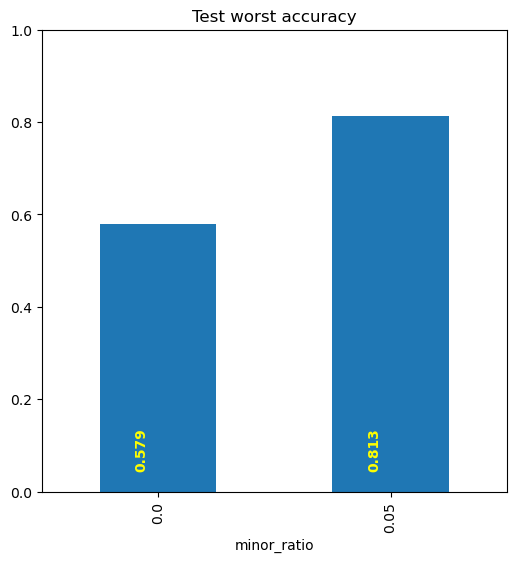

In [9]:
idx = get_best_index(df_queried_erm, var_list, 'valid_valid_best_worst_acc')

best_mean_erm = get_mean_with_given_index(df_queried_erm, var_list, 'test_worst_acc', idx)
best_std_erm = get_std_with_given_index(df_queried_erm, var_list, 'test_worst_acc', idx)
erm_test_acc_mean = get_mean_with_given_index(df_queried_erm, var_list, 'test_acc', idx)
erm_test_acc_std = get_std_with_given_index(df_queried_erm, var_list, 'test_acc', idx)

fig, ax = plt.subplots(1,1, figsize=(6,6))
xaxis= [str(i) for i in best_mean_erm.keys()]

best_mean_erm.plot(ax=ax, kind='bar', yerr=best_std_erm, capsize=7, title='Test worst accuracy', ylim=(0.0, 1))

for i, v in enumerate(best_mean_erm.values):
    ax.text(i - 0.1 , 0.05, str(f'{v:.3f}'), color='yellow', fontweight='bold', rotation=90)

fig.show()

In [10]:
var_list = ['set_last_layer', 'minor_ratio', 'batch_size_train', 'learning_rate']
df_mean = df_queried_erm.groupby(var_list)['valid_valid_best_worst_acc'].mean().sort_index()
idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()['valid_valid_best_worst_acc'].dropna()


to_be_queried = df_mean.reset_index().iloc[idx][var_list]
ids = df_queried_erm.set_index(var_list).loc[to_be_queried.set_index(var_list).index]['id']

In [11]:
ids = ids.reset_index()['id']

In [12]:
df_tmp = df_queried_erm.query('id in @ids')

In [13]:
var_list += ['data_seed', 'id']
df_tmp[var_list]

,set_last_layer,minor_ratio,batch_size_train,learning_rate,data_seed,id
203,three_layer,0.0000,32,0.0030,1234,WAT8-37
201,three_layer,0.0000,32,0.0030,1235,WAT8-39
196,three_layer,0.0000,32,0.0030,1236,WAT8-44
226,three_layer,0.0500,32,0.0010,1234,WAT8-14
230,three_layer,0.0500,32,0.0010,1235,WAT8-10
233,three_layer,0.0500,32,0.0010,1236,WAT8-7


In [14]:
import os

workspace_path = '/home/jj/Research/ConceptualSensitivityRegularization'

print(f"G_PATH='{workspace_path}/.neptune/temp/TEM-610/checkpoints/last.ckpt'")

print()

for LL, MR, BS, LR, SEED, ID in df_tmp[var_list].values:
    print(f"LL={LL}")
    print(f"MR={MR}")
    print(f"BS={BS}")
    print(f"LR={LR}")
    print(f"SEED={SEED}")

    ls = os.listdir(f'.neptune/{project_name}/{ID}/checkpoints/')
    ls.remove('last.ckpt')
    path = ls[0]
    print(f"MODEL_PATH='{workspace_path}/.neptune/{project_name}/{ID}/checkpoints/last.ckpt'")
    print("""for CS_METHOD in dot_sq
do""")

    for gpu_id, cs in enumerate([1e-1, 1e-0, 1e+1, 1e+2, 1e+3, 1e+4, 1e+5, 1e+6]):
        print(f"CUDA_VISIBLE_DEVICES={gpu_id%4} python -m csr.main $DEFAULTS \
--seed_everything $SEED --model.minor_ratio $MR --model.batch_size_train $BS --model.learning_rate $LR --model.set_last_layer $LL --model.lamb_cs {cs} --model.lamb_cav 0 --model.g_ckpt_path $G_PATH --model.model_path $MODEL_PATH --model.cs_method $CS_METHOD & ")
    print('wait\ndone\n')



print("""done
done
done""")

G_PATH='/home/jj/Research/ConceptualSensitivityRegularization/.neptune/temp/TEM-610/checkpoints/last.ckpt'

LL=three_layer
MR=0.0
BS=32
LR=0.003
SEED=1234


FileNotFoundError: [Errno 2] No such file or directory: '.neptune/240411WaterBirds/WAT8-37/checkpoints/'